## **<font color="red">InMemoryStore</font>**

In [1]:
from typing import Dict, Any

from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_ollama import ChatOllama
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore


# =========================
# 1. Initialize LLM
# =========================
llm = ChatOllama(
    model="qwen3:1.7b",
    temperature=0.5,
)

llm

ChatOllama(model='qwen3:1.7b', temperature=0.5)

In [2]:
# =========================
# 2. Create Long-Term Memory Store
# =========================
store = InMemoryStore()
user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; This keeps it easy.
user_namespace = ("user", user_id, "details")

store.put(user_namespace, "profile_1", {"data": "Name: Vikas"})
store.put(user_namespace, "profile_2", {"data": "Profession: Teachers AI on YouTube"})
store.put(user_namespace, "preference_1", {"data": "Prefers concise answers"})
store.put(user_namespace, "preference_2", {"data": "Likes examples in Python"})
store.put(user_namespace, "project_1", {"data": "Building MCP servers (Python-based profile)"})


In [3]:
# =========================
# 3. System Prompt Template
# =========================
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.

If user-specific memory is available, use it to personalize
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    - Addressing the user by name (e.g., "Sure, Vikas...") when appropriate
    - Referencing known projects, tools, or preferences (e.g., "Your MCP server python based project")
    - Adjusting the tone to feel friendly and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..."
say "Since your project is built with TypeScript..."

Use personalization especially in:
    - Greetings and transitions
    - Tool/framework-specific guidance
    - Follow-up messages

Always ensure personalization is based only on known user details.

In the end suggest 3 relevant further questions based on the current response and user profile.

The user's memory (which may be empty) is provided as:
{user_details_content}
"""


In [4]:
# =========================
# 4. Chat Node
# =========================
def chat_node(
    state: MessagesState,
    config: RunnableConfig,
    *,
    store: BaseStore,
) -> Dict[str, Any]:

    user_id = config["configurable"]["user_id"]
    # Read-only: fetch user details memory (no writes)
    user_namespace = ("user", user_id, "details")

    # Fetch memory (read-only)
    items = store.search(user_namespace)

    # Sort for deterministic output (good for teaching/debugging)
    items = sorted(items, key=lambda x: x.key)

    if items:
        user_details_content = "\n".join(
            f"- {item.value.get('data', '')}" for item in items
        )
    else:
        user_details_content = ""

    # Create system message
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_message = SystemMessage(content=system_prompt)

    # Invoke LLM
    response: AIMessage = llm.invoke(
        [system_message] + state["messages"]
    )

    return {"messages": [response]}



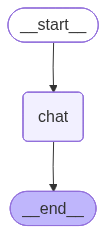

In [5]:
# =========================
# 5. Build Graph
# =========================
builder = StateGraph(MessagesState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [6]:
# =========================
# 6. Run Graph
# =========================
config = {"configurable": {"user_id": "u1"}}  # RunnableConfig

result = graph.invoke(
    {
        "messages": [
            HumanMessage(content="Explain gen ai in simple terms.")
        ]
    },
    config,
)

print(result["messages"][-1].content)


Sure, Vikas! Generative AI (Gen AI) is like a super smart computer that can create new things, like text, images, music, or even code. It doesn’t just follow existing data—it makes up new content based on patterns it learns. For example, it could generate a random sentence, a picture, or a Python script. 

Since your work involves Python and MCP servers, maybe you’re interested in using Gen AI for tasks like automating content creation or generating code snippets? 

**Three relevant questions:**  
1. How do you integrate Gen AI into your Python-based MCP server projects?  
2. Are there specific generative tasks (e.g., text generation, image creation) you’d like to explore in your workflow?  
3. What challenges do you face when using Gen AI for creative or technical tasks?  

Let me know if you’d like examples or further details! 😊
